# Data Prep for Predicting Perceived Effectiveness

**Data-prep pass only — no modeling here.** This notebook loads, cleans, and merges everything
needed to predict the pooled `perceived_effectiveness_z` composite (built in
`analysis/target_index_eda.ipynb`) from:

1. **The 12 features used in the HMM analysis** (`icmi_paper/results/hmm_input_features_final.tsv`)
   — physiology (HR, EDA, temp, pupil), speech/floor dynamics (silence, backchannels, laughter,
   active speakers), and overlap features (count, contested, time, collaboration index).
2. **The new windowed audio/prosodic features**
   (`icmi_paper/results/audio_window_features.tsv`) — energy, pitch mean/sd, HNR — not previously
   available at 30s-window granularity, not used in the HMM.

**Granularity decision:** HMM/audio features are window-level (30s), group-aggregated (no
per-participant signal). The effectiveness target is participant-level. Following the same
convention already used in `icmi_paper/analysis/hmm_state_prediction.ipynb` (self-report outcomes
aggregated to group×task before correlating with HMM states), this notebook aggregates **both**
sides to **group × task** (mean across windows for features, mean across P1–P4 for the target).

**Sections:**
1. Load HMM + audio window features, merge
2. Preprocessing (mirrors the HMM notebook's z-scoring / log1p choices; audio features z-scored the same way)
3. Aggregate window-level features to group×task
4. Load and aggregate the effectiveness target to group×task
5. Merge into the final modeling table (`model_df`) — hand off point for modeling

No new packages are needed (pandas/numpy/scikit-learn already installed). `model_df` at the end
has `X_COLS` (16 features + task dummies) and `Y_COL = "perceived_effectiveness_z"` ready to model.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style="whitegrid", font_scale=1.0)
%matplotlib inline

REPO_ROOT = Path.cwd() if (Path.cwd() / "icmi_paper").exists() else Path.cwd().parent
ICMI_RESULTS = REPO_ROOT / "icmi_paper" / "results"
TARGET_PATH = REPO_ROOT / "analysis" / "results" / "perceived_effectiveness_index_participant.tsv"
TASKS = ["T1", "T2", "T3"]

for p in [ICMI_RESULTS / "hmm_input_features_final.tsv", ICMI_RESULTS / "audio_window_features.tsv", TARGET_PATH]:
    assert p.exists(), f"Missing file: {p}"
print("All source files found.")


All source files found.


## 1. Load HMM window features + new audio window features

Both files are window-level (`group_id`, `task_id`, `window_index`), 526 rows, same 10 groups, and
the join keys match exactly (verified: 0 mismatches between the two key sets).


In [2]:
# The 12 features actually used in the HMM (icmi_paper/analysis/hmm_collective_states_updated_overlaps.ipynb, CLEAN_FEATS)
HMM_FEATS = [
    "group_hr_mean_bpm_mean",
    "group_eda_phasic_rate_hz_mean",
    "group_temp_mean_mean",
    "group_et_pupil_mean_mean",
    "tr_silence_duration_s",
    "tr_backchannel_count",
    "tr_laughter_count",
    "tr_n_active_speakers",
    "tr_ovl_count",
    "tr_ovl_contested",
    "tr_ovl_time_s",
    "tr_ovl_collaboration_index",
]

# Curated audio summary features (feature_inventory.md §6 "would add" list) — not gemap_* internals,
# to keep the feature/n ratio sane given only ~30 group×task rows downstream.
AUDIO_FEATS = ["audio_energy_mean", "audio_pitch_mean", "audio_pitch_sd", "audio_hnr_mean"]

KEY = ["group_id", "task_id", "window_index"]

hmm_win = pd.read_csv(ICMI_RESULTS / "hmm_input_features_final.tsv", sep="\t")
audio_win = pd.read_csv(ICMI_RESULTS / "audio_window_features.tsv", sep="\t")

print(f"HMM window features: {hmm_win.shape}")
print(f"Audio window features: {audio_win.shape}")

merged = hmm_win[KEY + HMM_FEATS].merge(audio_win[KEY + AUDIO_FEATS], on=KEY, how="inner")
assert len(merged) == len(hmm_win), "Merge dropped rows — key mismatch between HMM and audio tables"
merged = merged[merged["task_id"].isin(TASKS)].reset_index(drop=True)

# grp-12/T3: EmotiBit (physio) was 100% off, so it's absent from hmm_input_features_final.tsv
# entirely. But its transcript/overlap features are unaffected and available in
# enhanced_features_final.tsv — recover them (physio + audio left NaN) so non-physio models
# (e.g. the overlap-only lean model) can use this row. Physio-dependent models should dropna first.
enh = pd.read_csv(ICMI_RESULTS / "enhanced_features_final.tsv", sep="\t")
recovered = enh[(enh["group_id"] == "grp-12") & (enh["task_id"] == "T3")].copy()
recovered["tr_ovl_contested"] = recovered["tr_ovl_competitive_timing"] + recovered["tr_ovl_floor_fight"]
recovered = recovered[KEY + HMM_FEATS]
for c in AUDIO_FEATS:
    recovered[c] = np.nan

merged = pd.concat([merged, recovered], ignore_index=True)
print(f"Recovered grp-12/T3 (physio+audio NaN, transcript features real): {len(recovered)} windows")

print(f"Merged window-level feature table: {merged.shape}")
print(f"Missing values: {merged[HMM_FEATS + AUDIO_FEATS].isnull().sum().sum()}")
merged.head()


HMM window features: (526, 16)
Audio window features: (526, 70)
Recovered grp-12/T3 (physio+audio NaN, transcript features real): 46 windows
Merged window-level feature table: (572, 19)
Missing values: 388


,group_id,task_id,window_index,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,tr_ovl_count,tr_ovl_contested,tr_ovl_time_s,tr_ovl_collaboration_index,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean
0,grp-07,T1,0,61.0829,0.2002,36.0375,2.8745,0.000,1.0,0.0,2.0,5.0,4.0,28.978,0.200000,0.109416,23.936003,0.207996,1.817083
1,grp-07,T1,1,61.7098,0.1753,36.0427,2.7528,1.917,0.0,0.0,1.0,4.0,4.0,30.429,0.000000,0.110551,23.453197,0.188979,1.165167
2,grp-07,T1,2,61.7187,0.1668,36.0457,2.8210,2.208,0.0,0.0,3.0,1.0,1.0,0.530,1.000000,0.065333,23.598001,0.195372,0.965169
3,grp-07,T1,3,64.4445,0.1751,36.0486,2.7260,2.189,1.0,0.0,2.0,3.0,2.0,6.770,0.666667,0.040099,13.577585,0.048265,-2.171262
4,grp-07,T1,4,70.7754,0.1588,36.0611,2.6987,10.855,0.0,0.0,2.0,1.0,0.0,0.240,0.000000,0.045782,10.576397,0.062348,-3.440011


## 2. Preprocessing (mirrors the HMM notebook's choices)

- Physiological features (`group_hr_mean_bpm_mean`, `group_eda_phasic_rate_hz_mean`,
  `group_temp_mean_mean`, `group_et_pupil_mean_mean`) → **z-scored within `group_id`** (removes
  session-level baseline drift).
- Right-skewed count/duration features (silence, backchannel, laughter, overlap counts/time,
  collaboration index) → **log1p**.
- New audio features → **z-scored within `group_id`**, same rationale as physio: absolute vocal
  energy/pitch/HNR carries speaker-mix and recording-level baseline differences across sessions
  that within-group standardization removes.


In [3]:
clean = merged.copy()

PHYSIO_Z = ["group_hr_mean_bpm_mean", "group_eda_phasic_rate_hz_mean",
            "group_temp_mean_mean", "group_et_pupil_mean_mean"]
LOG_FEATS = ["tr_silence_duration_s", "tr_backchannel_count", "tr_laughter_count",
             "tr_ovl_count", "tr_ovl_contested", "tr_ovl_time_s", "tr_ovl_collaboration_index"]

for col in PHYSIO_Z + AUDIO_FEATS:
    clean[col] = clean.groupby("group_id")[col].transform(lambda x: (x - x.mean()) / (x.std(ddof=1) + 1e-9))

for col in LOG_FEATS:
    clean[col] = np.log1p(clean[col].clip(lower=0))

FEATURE_COLS = HMM_FEATS + AUDIO_FEATS
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
clean[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(2)


Feature columns (16): ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean', 'group_et_pupil_mean_mean', 'tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count', 'tr_n_active_speakers', 'tr_ovl_count', 'tr_ovl_contested', 'tr_ovl_time_s', 'tr_ovl_collaboration_index', 'audio_energy_mean', 'audio_pitch_mean', 'audio_pitch_sd', 'audio_hnr_mean']


,mean,std,min,max
group_hr_mean_bpm_mean,0.00,0.99,-2.89,2.68
group_eda_phasic_rate_hz_mean,0.00,0.99,-2.67,3.23
group_temp_mean_mean,0.00,0.99,-2.79,1.91
group_et_pupil_mean_mean,-0.00,0.99,-2.66,2.50
tr_silence_duration_s,1.85,0.98,0.00,5.28
tr_backchannel_count,0.70,0.64,0.00,2.48
tr_laughter_count,0.22,0.43,0.00,2.20
tr_n_active_speakers,2.12,1.16,0.00,4.00
tr_ovl_count,0.43,0.69,0.00,2.77
tr_ovl_contested,0.27,0.53,0.00,2.48


## 3. Aggregate window-level features to group × task

Mean across all windows within each group×task (a std-of-windows version would add
within-task variability as a second signal — worth trying later, not in this first pass).


In [4]:
feat_task = (
    clean.groupby(["group_id", "task_id"])[FEATURE_COLS]
    .mean()
    .reset_index()
    .rename(columns={"task_id": "task"})
)

n_windows = clean.groupby(["group_id", "task_id"]).size().reset_index(name="n_windows")
print(f"Group x task feature rows: {feat_task.shape}")
print(f"Windows per group-task: min={n_windows['n_windows'].min()}, "
      f"max={n_windows['n_windows'].max()}, mean={n_windows['n_windows'].mean():.1f}")
feat_task.head()


Group x task feature rows: (28, 18)
Windows per group-task: min=9, max=46, mean=20.4


,group_id,task,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,tr_ovl_count,tr_ovl_contested,tr_ovl_time_s,tr_ovl_collaboration_index,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean
0,grp-07,T1,-0.236569,-0.940738,-1.279399,-0.833466,1.564436,0.430133,0.000000,1.888889,0.685976,0.556737,1.059872,0.154033,-0.283550,-0.618567,-0.268004,-0.552627
1,grp-07,T2,0.088869,-0.008194,0.856327,0.296030,1.471789,0.286756,0.102688,2.111111,0.614669,0.427743,0.778808,0.102021,0.417037,0.347991,-0.051969,0.456120
2,grp-07,T3,-0.020796,0.668299,-0.892788,-0.037818,1.886348,0.883425,0.266595,2.692308,1.124988,0.944076,1.263580,0.109436,-0.669850,-0.294512,0.293478,-0.564738
3,grp-08,T1,-0.192485,-0.409371,1.103430,-0.315863,2.183859,0.147555,0.099396,1.400000,0.399218,0.182574,0.258580,0.059036,-0.286397,-0.318426,-0.078017,-0.160808
4,grp-08,T2,-0.169970,0.085868,0.112212,0.480927,2.164400,0.361963,0.085011,1.676471,0.549440,0.290078,0.414468,0.077338,0.413460,0.230067,0.098246,0.116466


## 4. Load the effectiveness target and aggregate to group × task

Source: `analysis/results/perceived_effectiveness_index_participant.tsv` (built in
`target_index_eda.ipynb`). Mean across P1–P4 within each group×task, same convention as
`hmm_state_prediction.ipynb` uses for other self-report outcomes.


In [5]:
target_participant = pd.read_csv(TARGET_PATH, sep='\t')

ALL_OUTCOMES = ['perceived_effectiveness_z', 'team_coordination',
                'cooperative', 'satisfaction', 'decision_confidence', 'idea_quality']
available_outcomes = [c for c in ALL_OUTCOMES if c in target_participant.columns]

target_task = (
    target_participant.groupby(['group_id', 'task'])[available_outcomes]
    .mean()
    .reset_index()
)

print(f'Target group x task rows: {target_task.shape}')
print(f'Outcome columns: {available_outcomes}')
target_task.groupby('task')[available_outcomes].mean().round(2)
# ── Add previously validated composite from HMM prediction results ─────────
_hmm_pred = pd.read_csv(ICMI_RESULTS / 'hmm_prediction_results.tsv', sep='\t')
_hmm_pred = _hmm_pred[['group_id', 'task_id', 'composite_actual']].rename(columns={'task_id': 'task'})
target_task = target_task.merge(_hmm_pred, on=['group_id', 'task'], how='left')
print(f'composite_actual NaNs: {target_task["composite_actual"].isna().sum()}')


Target group x task rows: (30, 8)
Outcome columns: ['perceived_effectiveness_z', 'team_coordination', 'cooperative', 'satisfaction', 'decision_confidence', 'idea_quality']


composite_actual NaNs: 3


## 5. Merge into the final modeling table

`task` is added as dummy variables — some HMM/audio features still carry task-driven mean
differences (e.g. T2 has lower `tr_ovl_collaboration_index` baseline), so the model needs task as
an explicit covariate rather than assuming the multimodal features alone are task-invariant.

`model_df` is 28 rows (not 30): `grp-09/T1` and `grp-13/T3` have no transcript at all, so they're
excluded entirely. `grp-12/T3` **is** included — its transcript/overlap features are real, but its
physio + audio columns are NaN (EmotiBit was off for that task) — see section 1. Any model using
only the transcript/overlap features (`tr_*`) can use all 28 rows; a model using physio or audio
must drop that one row (or impute, not done here).


In [6]:
model_df = feat_task.merge(target_task, on=["group_id", "task"], how="inner")
dropped = set(zip(target_task["group_id"], target_task["task"])) - set(zip(model_df["group_id"], model_df["task"]))

task_dummies = pd.get_dummies(model_df["task"], prefix="task", drop_first=True)
model_df = pd.concat([model_df, task_dummies], axis=1)

TASK_DUMMY_COLS = list(task_dummies.columns)
X_COLS = FEATURE_COLS + TASK_DUMMY_COLS
Y_COL = "perceived_effectiveness_z"

print(f"Final modeling table: {model_df.shape}  (30 possible group x task combos, {len(dropped)} missing entirely)")
print(f"Missing group-task combos (no transcript at all): {sorted(dropped)}")
print(f"Groups: {model_df['group_id'].nunique()}, tasks: {sorted(model_df['task'].unique())}")

# grp-12/T3 has real transcript/overlap features but NaN physio+audio (EmotiBit was off) —
# drop physio+audio columns (or dropna()) before fitting any model that needs a complete matrix.
na_counts = model_df[X_COLS + [Y_COL]].isnull().sum()
na_counts = na_counts[na_counts > 0]
if len(na_counts):
    print(f"Columns with NaNs (only for grp-12/T3): \n{na_counts}")
model_df.head()


Final modeling table: (28, 27)  (30 possible group x task combos, 2 missing entirely)
Missing group-task combos (no transcript at all): [('grp-09', 'T1'), ('grp-13', 'T3')]
Groups: 10, tasks: ['T1', 'T2', 'T3']
Columns with NaNs (only for grp-12/T3): 
group_hr_mean_bpm_mean           1
group_eda_phasic_rate_hz_mean    1
audio_energy_mean                1
audio_pitch_mean                 1
audio_pitch_sd                   1
audio_hnr_mean                   1
dtype: int64


,group_id,task,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,...,audio_hnr_mean,perceived_effectiveness_z,team_coordination,cooperative,satisfaction,decision_confidence,idea_quality,composite_actual,task_T2,task_T3
0,grp-07,T1,-0.236569,-0.940738,-1.279399,-0.833466,1.564436,0.430133,0.000000,1.888889,...,-0.552627,0.676091,6.50,NaN,NaN,6.75,NaN,6.50,False,False
1,grp-07,T2,0.088869,-0.008194,0.856327,0.296030,1.471789,0.286756,0.102688,2.111111,...,0.456120,-0.082174,NaN,3.75,5.25,NaN,NaN,3.75,True,False
2,grp-07,T3,-0.020796,0.668299,-0.892788,-0.037818,1.886348,0.883425,0.266595,2.692308,...,-0.564738,0.373228,6.75,NaN,6.00,NaN,5.75,6.75,False,True
3,grp-08,T1,-0.192485,-0.409371,1.103430,-0.315863,2.183859,0.147555,0.099396,1.400000,...,-0.160808,0.056174,5.25,NaN,NaN,6.50,NaN,5.25,False,False
4,grp-08,T2,-0.169970,0.085868,0.112212,0.480927,2.164400,0.361963,0.085011,1.676471,...,0.116466,0.450684,NaN,3.75,5.50,NaN,NaN,3.75,True,False


## 6. Merge New Feature Sets: BERT-UMAP · Keyword DA · NLI DA

Window-level files are aggregated to group × task (mean across windows, valid windows only for BERT).
NLI DA features are prefixed `nli_` to avoid collision with keyword DA columns.
Feature counts are kept small (5 per modality) given n=28 group × task rows.

In [7]:
# Load collective selfreport file — has voice_inclusion and mental_demand for all tasks
SELFREPORT_PATH = REPO_ROOT / 'analysis' / 'results' / 'collective_features_v20260812' / 'collective_task_selfreport.tsv'
sr = pd.read_csv(SELFREPORT_PATH, sep='\t').rename(columns={'task_id': 'task'})

SR_OUTCOMES = ['voice_inclusion_mean', 'mental_demand_mean',
               'team_coordination_mean', 'cooperative_mean', 'satisfaction_mean',
               'decision_confidence_mean', 'idea_quality_mean']
SR_OUTCOMES = [c for c in SR_OUTCOMES if c in sr.columns]

model_df3 = model_df.merge(sr[['group_id', 'task'] + SR_OUTCOMES], on=['group_id', 'task'], how='left')

# Combined cross-task z-score: team_coordination (T1/T3) and cooperative (T2), within-task centred
for col, tasks in [('team_coordination_mean', ['T1', 'T3']), ('cooperative_mean', ['T2'])]:
    mask = model_df3['task'].isin(tasks)
    vals = model_df3.loc[mask, col]
    model_df3.loc[mask, '_coord_coop_z'] = (vals - vals.mean()) / (vals.std(ddof=1) + 1e-9)

print(f'model_df3 shape: {model_df3.shape}')
print('Outcome NaN counts:')
print(model_df3[SR_OUTCOMES + ['_coord_coop_z']].isnull().sum().to_string())
# ── Old HMM state proportions (icmi_paper, K=5) ────────────────────────────────
_old_hmm = pd.read_csv(ICMI_RESULTS / 'hmm_prediction_results.tsv', sep='\t')
_old_hmm = _old_hmm.rename(columns={'task_id': 'task'})
_raw_old_cols = [c for c in ['S0_pct','S1_pct','S2_pct','S3_pct','S4_pct'] if c in _old_hmm.columns]
_rename_old = {c: f'old_{c}' for c in _raw_old_cols}
_old_hmm = _old_hmm.rename(columns=_rename_old)
HMM_OLD_STATE_FEATS = list(_rename_old.values())
model_df3 = model_df3.merge(_old_hmm[['group_id','task'] + HMM_OLD_STATE_FEATS], on=['group_id','task'], how='left')

# ── New HMM state proportions (expanded features, K=4) ───────────────────────────
_new_hmm_path = REPO_ROOT / 'analysis' / 'results' / 'hmm_state_proportions_expanded.tsv'
if _new_hmm_path.exists():
    _new_hmm = pd.read_csv(_new_hmm_path, sep='\t')
    _new_hmm = _new_hmm.rename(columns={'task_id': 'task'}) if 'task_id' in _new_hmm.columns else _new_hmm
    _raw_new_cols = [c for c in _new_hmm.columns if c.endswith('_pct')]
    _rename_new = {c: f'new_{c}' for c in _raw_new_cols}
    _new_hmm = _new_hmm.rename(columns=_rename_new)
    HMM_NEW_STATE_FEATS = list(_rename_new.values())
    model_df3 = model_df3.merge(_new_hmm[['group_id','task'] + HMM_NEW_STATE_FEATS], on=['group_id','task'], how='left')
    print(f'New HMM states: {HMM_NEW_STATE_FEATS}')
else:
    HMM_NEW_STATE_FEATS = []
    print('New HMM state file not found — skipping')

print(f'model_df3 shape: {model_df3.shape}')


model_df3 shape: (28, 35)
Outcome NaN counts:
voice_inclusion_mean         0
mental_demand_mean           0
team_coordination_mean      10
cooperative_mean            18
satisfaction_mean            9
decision_confidence_mean    19
idea_quality_mean           19
_coord_coop_z                0


New HMM states: ['new_S0_pct', 'new_S1_pct', 'new_S2_pct', 'new_S3_pct']
model_df3 shape: (28, 44)


## 7. Modality-Stratified Prediction (LOGO-CV Ridge)

Each modality is tested in isolation and in combination with the HMM baseline.  
Task dummies are included in every model as covariates (controls for task-level means).  
Leave-One-Group-Out CV (n=10 groups) — consistent with `hmm_lexical_prediction.ipynb`.

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization is generated after cell 9 runs — see below.
# This cell is a pass-through; the heatmap is at the end.
print('Visualization deferred to after model fitting.')


Visualization deferred to after model fitting.


## Section 2: Model Comparison

Compare Ridge, Lasso, ElasticNet, and Random Forest on the same targets using L2GO.
- **Lasso**: automatic feature selection (L1 penalty)
- **ElasticNet**: L1+L2, handles correlated features
- **RF**: non-linear, produces feature importances


In [9]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr

# ── Load the ACTUAL 19 features used in the expanded HMM (04_latent_group_states) ──
_wf = pd.read_csv(REPO_ROOT / "analysis" / "results" / "collective_features_v20260812" / "window_features_30s.tsv", sep="\t") \
    if (REPO_ROOT / "analysis" / "results" / "collective_features_v20260812" / "window_features_30s.tsv").exists() \
    else None

# The 19 features from the expanded HMM notebook (cell 6)
EXPANDED_HMM_RAW = [
    "group_hr_mean_bpm_mean", "group_eda_phasic_rate_hz_mean",
    "group_hrv_rmssd_ms_mean", "group_eda_tonic_mean_mean",
    "group_temp_mean_mean", "group_et_pupil_mean_mean",
    "tr_silence_duration_s", "tr_backchannel_count", "tr_overlap_count",
    "tr_competitive_overlap", "tr_laughter_count", "tr_n_active_speakers",
    "tr_speaking_entropy", "tr_cooperative_overlap", "tr_collaborative_overlap",
    "lex_word_gini", "lex_we_i_ratio", "lex_turn_cohesion", "lex_hedging_count",
]

# Load enhanced features (has the transcript/overlap features)
_enh = pd.read_csv(ICMI_RESULTS / "enhanced_features_final.tsv", sep="\t")
_enh = _enh.rename(columns={"task_id": "task"}) if "task_id" in _enh.columns else _enh

# Load lexical window features
_lex = pd.read_csv(REPO_ROOT / "analysis" / "results" / "lexical_window_30s.tsv", sep="\t")
_lex = _lex.rename(columns={"task_id": "task"}) if "task_id" in _lex.columns else _lex

# Load DA keyword features
_da = pd.read_csv(REPO_ROOT / "analysis" / "results" / "da_keyword_window_30s.tsv", sep="\t")
_da = _da.rename(columns={"task_id": "task"}) if "task_id" in _da.columns else _da

# Load completion/repetition
_cr = pd.read_csv(REPO_ROOT / "analysis" / "results" / "completion_repetition_window_30s.tsv", sep="\t")
_cr = _cr.rename(columns={"task_id": "task"}) if "task_id" in _cr.columns else _cr

# Load semantic continuity
_sem = pd.read_csv(REPO_ROOT / "analysis" / "results" / "semantic_continuity_window_30s.tsv", sep="\t")
_sem = _sem.rename(columns={"task_id": "task"}) if "task_id" in _sem.columns else _sem

# Aggregate all to group x task
KEY_GT = ["group_id", "task"]

# Enhanced features → group x task
_enh_cols_use = [c for c in EXPANDED_HMM_RAW if c in _enh.columns]
_enh_extra = ["tr_speaking_entropy", "tr_cooperative_overlap", "tr_collaborative_overlap",
              "tr_competitive_overlap", "tr_overlap_count", "tr_filled_pause_count",
              "tr_conflict_overlap_ratio", "tr_ovl_smooth", "tr_ovl_floor_fight",
              "tr_ovl_competitive_timing", "tr_ovl_completion_index",
              "group_hrv_rmssd_ms_mean", "group_eda_tonic_mean_mean"]
_enh_all = list(set(_enh_cols_use + [c for c in _enh_extra if c in _enh.columns]))
enh_task = _enh.groupby(KEY_GT)[_enh_all].mean().reset_index()

# Theory-driven lexical features
LEX_THEORY = ["lex_we_i_ratio", "lex_turn_cohesion", "lex_word_gini",
              "lex_hedging_count", "lex_agreement_count", "lex_question_count",
              "lex_suggestion_count", "lex_social_composite", "lex_sentiment_ratio"]
LEX_THEORY = [c for c in LEX_THEORY if c in _lex.columns]
lex_task = _lex.groupby(KEY_GT)[LEX_THEORY].mean().reset_index()

# DA features
DA_FEATS = ["da_agreement", "da_disagreement", "da_compromise", "da_proposal",
            "da_question", "da_hedge", "da_backchannel"]
DA_FEATS = [c for c in DA_FEATS if c in _da.columns]
da_task = _da.groupby(KEY_GT)[DA_FEATS].mean().reset_index()

# Completion/repetition + semantic
CR_FEATS = ["tr_completion_count", "tr_repetition_count"]
cr_task = _cr.groupby(KEY_GT)[CR_FEATS].mean().reset_index()
SEM_FEATS = ["tr_semantic_continuity", "tr_cross_speaker_similarity"]
sem_task = _sem.groupby(KEY_GT)[SEM_FEATS].mean().reset_index()

# Merge all into model_df3
for df_merge, name in [(enh_task, "enhanced"), (lex_task, "lexical"),
                       (da_task, "DA"), (cr_task, "compl/rep"), (sem_task, "semantic")]:
    cols_before = set(model_df3.columns)
    new_cols = [c for c in df_merge.columns if c not in KEY_GT and c not in cols_before]
    if new_cols:
        model_df3 = model_df3.merge(df_merge[KEY_GT + new_cols], on=KEY_GT, how="left")
        print(f"  Merged {name}: {new_cols}")

# ── Define feature sets ───────────────────────────────────────────────────────
# Expanded raw = the 19 features that went into the K=4 HMM
EXPANDED_RAW = [c for c in EXPANDED_HMM_RAW if c in model_df3.columns]
print(f"\nExpanded HMM raw features available: {len(EXPANDED_RAW)}/{len(EXPANDED_HMM_RAW)}")

# Turn-taking/overlap block (from enhanced)
TURN_TAKING = [c for c in ["tr_silence_duration_s", "tr_backchannel_count",
    "tr_n_active_speakers", "tr_speaking_entropy", "tr_overlap_count",
    "tr_competitive_overlap", "tr_cooperative_overlap", "tr_collaborative_overlap",
    "tr_filled_pause_count", "tr_conflict_overlap_ratio",
    "tr_ovl_smooth", "tr_ovl_floor_fight", "tr_ovl_completion_index"]
    if c in model_df3.columns]

MODALITY_SETS = {
    "HMM states (K=4)":      HMM_NEW_STATE_FEATS,
    "HMM states (K=5)":      HMM_OLD_STATE_FEATS,
    "Expanded raw (19)":      EXPANDED_RAW,
    "Turn-taking only":       TURN_TAKING,
    "Lexical (theory)":       LEX_THEORY,
    "DA keywords":            DA_FEATS,
    "Semantic + completion":  SEM_FEATS + CR_FEATS,
    "Audio":                  AUDIO_FEATS,
    "States + Turn-taking":   HMM_NEW_STATE_FEATS + TURN_TAKING,
    "States + Lexical":       HMM_NEW_STATE_FEATS + LEX_THEORY,
    "States + DA":            HMM_NEW_STATE_FEATS + DA_FEATS,
    "States + Lex + DA":      HMM_NEW_STATE_FEATS + LEX_THEORY + DA_FEATS,
    "Turn + Lex + DA":        TURN_TAKING + LEX_THEORY + DA_FEATS,
}

for name, feats in MODALITY_SETS.items():
    avail = [c for c in feats if c in model_df3.columns]
    print(f"  {name}: {len(avail)} features")

TARGETS = {
    "effectiveness_z":     (["T1","T2","T3"], "perceived_effectiveness_z"),
    "voice_inclusion":     (["T1","T2","T3"], "voice_inclusion_mean"),
    "mental_demand":       (["T1","T2","T3"], "mental_demand_mean"),
    "coord+coop":          (["T1","T2","T3"], "_coord_coop_z"),
    "cooperative":         (["T2"],           "cooperative_mean"),
    "team_coordination":   (["T1","T3"],      "team_coordination_mean"),
    "satisfaction":        (["T2","T3"],       "satisfaction_mean"),
    "decision_confidence": (["T1"],            "decision_confidence_mean"),
    "idea_quality":        (["T3"],            "idea_quality_mean"),
}

N_PERM = 100

def logo_ridge(feature_cols, target_col, task_filter):
    df = model_df3[model_df3["task"].isin(task_filter)].copy()
    if target_col not in df.columns or df[target_col].isna().all():
        return {"R2": float("nan"), "MAE": float("nan"), "rho": float("nan"), "perm_p": float("nan")}
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    cols = [c for c in feature_cols if c in df.columns] + task_cols
    if not cols:
        return {"R2": float("nan"), "MAE": float("nan"), "rho": float("nan"), "perm_p": float("nan")}
    X = df[cols].values.astype(float)
    y = df[target_col].values.astype(float)
    g = df["group_id"].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    X_m, y_m, g_m = X[mask], y[mask], g[mask]
    if mask.sum() < max(3, len(np.unique(g_m))):
        return {"R2": float("nan"), "MAE": float("nan"), "rho": float("nan"), "perm_p": float("nan")}
    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
    preds = cross_val_predict(pipe, X_m, y_m, cv=LeaveOneGroupOut(), groups=g_m)
    r2 = r2_score(y_m, preds)
    mae = mean_absolute_error(y_m, preds)
    rho, _ = spearmanr(y_m, preds)
    rng = np.random.default_rng(42)
    n_better = sum(
        r2_score(y_s := rng.permutation(y_m),
                 cross_val_predict(make_pipeline(StandardScaler(),
                     RidgeCV(alphas=[0.01,0.1,1,10,100])), X_m, y_s,
                     cv=LeaveOneGroupOut(), groups=g_m)) >= r2
        for _ in range(N_PERM))
    perm_p = (n_better + 1) / (N_PERM + 1)
    return {"R2": round(r2, 3), "MAE": round(mae, 3), "rho": round(rho, 3), "perm_p": round(perm_p, 3)}

rows = []
total = len(MODALITY_SETS) * len(TARGETS)
done = 0
for m_name, feats in MODALITY_SETS.items():
    for t_name, (tasks, t_col) in TARGETS.items():
        done += 1
        print(f"  [{done}/{total}] {m_name} -> {t_name}", end="", flush=True)
        res = logo_ridge(feats, t_col, tasks)
        res["Model"] = m_name
        res["Target"] = t_name
        rows.append(res)
        print(f"  R2={res['R2']}")

model_comp = pd.DataFrame(rows)

print("\n=== LOGO-CV Ridge R\u00b2 ===")
pivot_r2 = model_comp.pivot(index="Model", columns="Target", values="R2")
print(pivot_r2.to_string())

print("\n=== Spearman \u03c1 ===")
pivot_rho = model_comp.pivot(index="Model", columns="Target", values="rho")
print(pivot_rho.to_string())

print("\n=== Permutation p-value (n=100) ===")
pivot_p = model_comp.pivot(index="Model", columns="Target", values="perm_p")
print(pivot_p.to_string())

model_comp.to_csv(REPO_ROOT / "analysis" / "results" / "prediction_model_comparison.tsv",
                  sep="\t", index=False)
print("\nSaved to analysis/results/prediction_model_comparison.tsv")


  Merged enhanced: ['tr_overlap_count', 'group_hrv_rmssd_ms_mean', 'tr_filled_pause_count', 'tr_collaborative_overlap', 'tr_ovl_smooth', 'tr_ovl_floor_fight', 'tr_ovl_competitive_timing', 'tr_conflict_overlap_ratio', 'tr_speaking_entropy', 'tr_ovl_completion_index', 'group_eda_tonic_mean_mean', 'tr_competitive_overlap', 'tr_cooperative_overlap']


  Merged lexical: ['lex_we_i_ratio', 'lex_turn_cohesion', 'lex_word_gini', 'lex_hedging_count', 'lex_agreement_count', 'lex_question_count', 'lex_suggestion_count', 'lex_social_composite', 'lex_sentiment_ratio']
  Merged DA: ['da_agreement', 'da_disagreement', 'da_compromise', 'da_proposal', 'da_question', 'da_hedge', 'da_backchannel']
  Merged compl/rep: ['tr_completion_count', 'tr_repetition_count']
  Merged semantic: ['tr_semantic_continuity', 'tr_cross_speaker_similarity']

Expanded HMM raw features available: 19/19
  HMM states (K=4): 4 features
  HMM states (K=5): 5 features
  Expanded raw (19): 19 features
  Turn-taking only: 13 features
  Lexical (theory): 9 features
  DA keywords: 7 features
  Semantic + completion: 4 features
  Audio: 4 features
  States + Turn-taking: 17 features
  States + Lexical: 13 features
  States + DA: 11 features
  States + Lex + DA: 20 features
  Turn + Lex + DA: 29 features
  [1/117] HMM states (K=4) -> effectiveness_z

  R2=-0.041
  [2/117] HMM states (K=4) -> voice_inclusion

  R2=0.342
  [3/117] HMM states (K=4) -> mental_demand

  R2=0.274
  [4/117] HMM states (K=4) -> coord+coop

...

  R2=-0.68
  [114/117] Turn + Lex + DA -> team_coordination

  R2=-0.616
  [115/117] Turn + Lex + DA -> satisfaction

  R2=-0.134
  [116/117] Turn + Lex + DA -> decision_confidence

  R2=-0.647
  [117/117] Turn + Lex + DA -> idea_quality

  R2=-0.299

=== LOGO-CV Ridge R² ===
Target                 cooperative  coord+coop  decision_confidence  effectiveness_z  idea_quality  mental_demand  satisfaction  team_coordination  voice_inclusion
Model                                                                                                                                                              
Audio                       -0.301      -0.064               -1.935           -0.263        -9.414          0.437         0.295             -0.957            0.135
DA keywords                 -3.421      -0.058               -2.040           -0.104        -0.372          0.109         0.001             -0.121            0.393
Expanded raw (19)            0.648       0.056                0.107           -0.269        -0.247         -1.234        -0.906              0.356            0.541
HMM states (K=4)            -0.277      -0.086               -0.441           -0.041        -0.377          0.274         0.239             -0

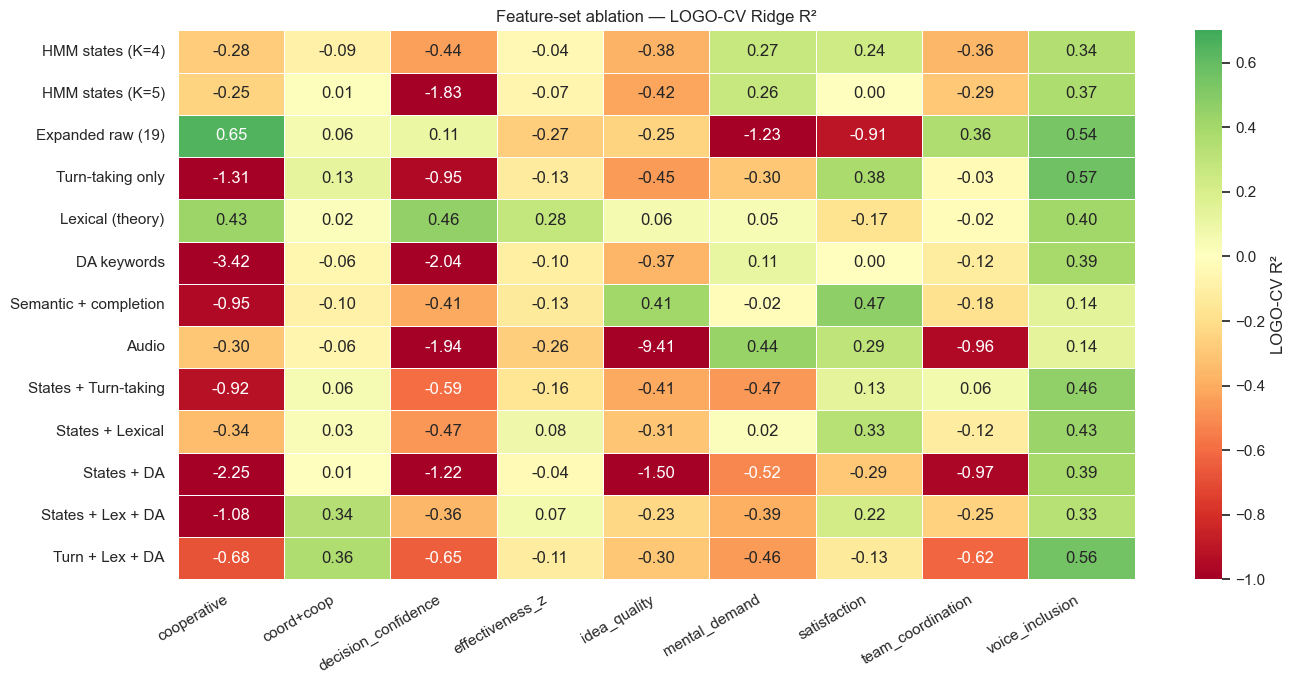


Significant (p < 0.05): 40 / 117
Target                cooperative coord+coop decision_confidence effectiveness_z idea_quality mental_demand satisfaction team_coordination voice_inclusion
Model                                                                                                                                                     
HMM states (K=4)            0.198      0.238               0.455           0.089        0.545        0.010*       0.030*             0.604          0.010*
HMM states (K=5)            0.089      0.050               0.861           0.168        0.188        0.010*        0.059             0.584          0.010*
Expanded raw (19)          0.020*     0.020*               0.089           0.545        0.238         0.832        0.851            0.020*          0.010*
Turn-taking only            0.851     0.010*               0.673           0.297        0.248         0.762       0.010*             0.050          0.010*
Lexical (theory)           0.020*   

In [10]:
import seaborn as sns

row_order = ["HMM states (K=4)", "HMM states (K=5)", "Expanded raw (19)",
             "Turn-taking only", "Lexical (theory)", "DA keywords",
             "Semantic + completion", "Audio",
             "States + Turn-taking", "States + Lexical", "States + DA",
             "States + Lex + DA", "Turn + Lex + DA"]
pivot = model_comp.pivot(index="Model", columns="Target", values="R2")
pivot = pivot.reindex([r for r in row_order if r in pivot.index])

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=0.7, linewidths=0.5, ax=ax,
            cbar_kws={"label": "LOGO-CV R\u00b2"})
ax.set_title("Feature-set ablation — LOGO-CV Ridge R\u00b2")
ax.set_ylabel(""); ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

pivot_p = model_comp.pivot(index="Model", columns="Target", values="perm_p")
pivot_p = pivot_p.reindex([r for r in row_order if r in pivot_p.index])
sig = (pivot_p < 0.05).sum().sum()
print(f"\nSignificant (p < 0.05): {sig} / {pivot_p.size}")
print(pivot_p.map(lambda x: f"{x:.3f}*" if x < 0.05 else f"{x:.3f}").to_string())
